<a href="https://colab.research.google.com/github/sebr22/sebr/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sebr22/sebr/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

The key traffic variables are strongly zero-inflated and right-skewed. In March 2026, 46.7% of observations had zero GSC impressions and 79.2% had zero GSC clicks. GA4 sessions were zero for 51.4% of observations, while 74.5% had zero recorded engaged sessions. Combined with the large maximum values observed in the summary statistics, this indicates that a relatively small number of pages account for much larger volumes of traffic and engagement. I will therefore avoid relying on raw Pearson correlations and use log-transformed or rank-based measures when testing relationships between these variables. I will also check data-availability flags before interpreting GA4 zeros, since a zero may reflect unavailable measurement rather than genuinely zero activity.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(f"""
CREATE SECRET hf_secret (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

rel = "hf://datasets/FlyRank/internship-warehouse"

con.sql(f"""
SELECT COUNT(*)
FROM read_parquet(
    '{rel}/fact_content_daily_performance/**/*.parquet'
)
""")

march_df = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS gsc_impressions,
        SUM(gsc_clicks) AS gsc_clicks,
        AVG(gsc_avg_position) AS gsc_avg_position,

        SUM(ga4_sessions) AS ga4_sessions,
        SUM(ga4_engaged_sessions) AS ga4_engaged_sessions,
        SUM(ga4_total_engagement_sec) AS ga4_total_engagement_sec,

        BOOL_OR(gsc_data_available) AS gsc_data_available,
        BOOL_OR(ga4_data_available) AS ga4_data_available

    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )

    WHERE report_date >= DATE '2026-03-01'
      AND report_date < DATE '2026-04-01'

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

import numpy as np

march_df["gsc_ctr"] = (
    march_df["gsc_clicks"] /
    march_df["gsc_impressions"].replace(0, np.nan)
).fillna(0)

march_df["engagement_rate"] = (
    march_df["ga4_engaged_sessions"] /
    march_df["ga4_sessions"].replace(0, np.nan)
).fillna(0)

feature_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "gsc_ctr",
    "ga4_sessions",
    "engagement_rate"
]

X = (
    march_df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [2]:
import matplotlib.pyplot as plt

distribution_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "gsc_ctr",
    "engagement_rate"
]

for col in distribution_cols:
    print(f"\n{col}")
    print(march_df[col].describe())


gsc_impressions
count    331437.000000
mean        846.790156
std        4044.514753
min           0.000000
25%           0.000000
50%           2.000000
75%         216.000000
max      617124.000000
Name: gsc_impressions, dtype: float64

gsc_clicks
count    331437.000000
mean          2.479602
std          19.651282
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        5668.000000
Name: gsc_clicks, dtype: float64

gsc_avg_position
count    176738.000000
mean         15.999277
std          17.686260
min           0.000000
25%           5.001970
50%           8.505296
75%          20.369190
max         309.000000
Name: gsc_avg_position, dtype: float64

ga4_sessions
count    260737.000000
mean          4.985131
std          28.524165
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        2730.000000
Name: ga4_sessions, dtype: float64

ga4_engaged_sessions
count    260737.000000
mean         

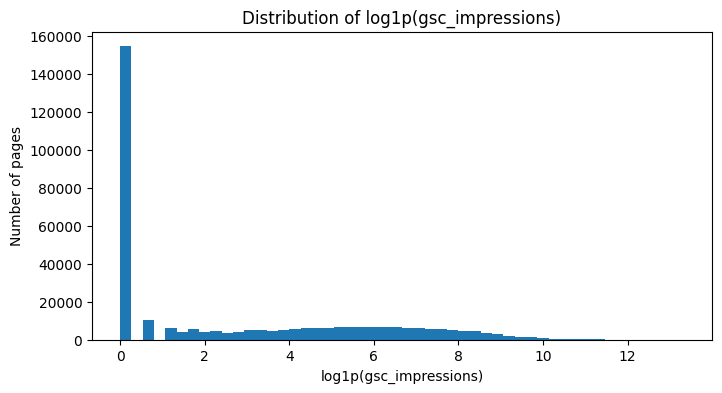

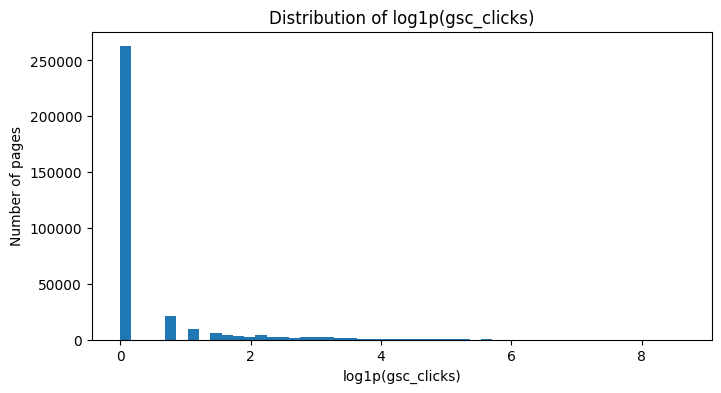

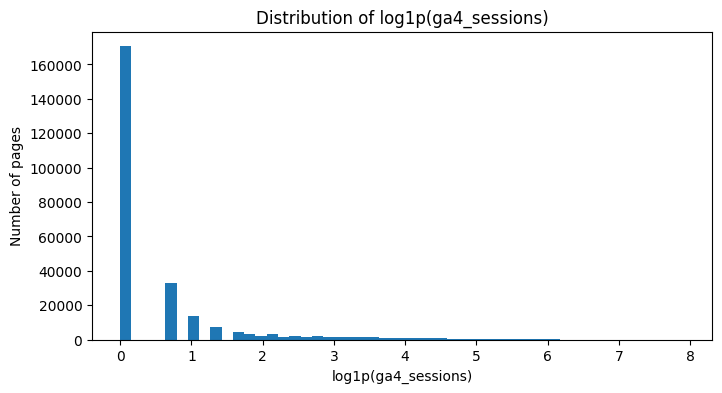

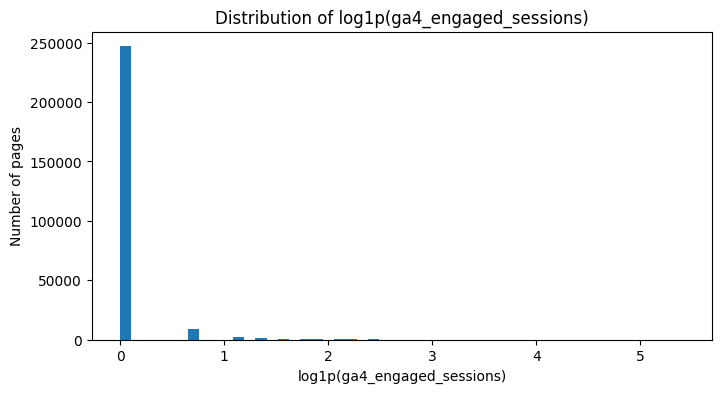

In [3]:
traffic_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "ga4_sessions",
    "ga4_engaged_sessions"
]

for col in traffic_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(np.log1p(march_df[col]), bins=50)
    plt.title(f"Distribution of log1p({col})")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Number of pages")
    plt.show()

In [4]:
cols = [
    "gsc_impressions",
    "gsc_clicks",
    "ga4_sessions",
    "ga4_engaged_sessions"
]

for col in cols:
    zero_pct = (march_df[col] == 0).mean() * 100
    print(f"{col}: {zero_pct:.1f}% zeros")

gsc_impressions: 46.7% zeros
gsc_clicks: 79.2% zeros
ga4_sessions: 51.4% zeros
ga4_engaged_sessions: 74.5% zeros


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*
###1.
Claim: Pages ranking in better average search positions tend to receive more search impressions.

Test: I grouped pages with valid GSC data into average-position bands and compared the median number of impressions in each group. I used groups with at least 50 observations to avoid drawing conclusions from very small samples.

Verdict: MIXED. Pages with very poor search positions (51+) have substantially lower median impressions than pages ranking in the top 50, supporting the idea that search position is related to visibility. However, the relationship is not consistently monotonic, as pages ranking 11–20 have slightly higher median impressions than those ranking 1–10. Search position therefore appears to be a useful signal, but it does not explain impressions on its own.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd

position_test = march_df[
    (march_df["gsc_avg_position"] > 0) &
    (march_df["gsc_impressions"] > 0)
].copy()

position_test["position_bucket"] = pd.cut(
    position_test["gsc_avg_position"],
    bins=[0, 3, 10, 20, 50, np.inf],
    labels=["1-3", "4-10", "11-20", "21-50", "51+"]
)

result = (
    position_test
    .groupby("position_bucket", observed=False)
    .agg(
        n=("gsc_impressions", "size"),
        median_impressions=("gsc_impressions", "median")
    )
)

print(result)

                     n  median_impressions
position_bucket                           
1-3              16144               249.0
4-10             81988               201.0
11-20            32203               257.0
21-50            33288               177.0
51+              11681                49.0


###2.
Claim: Pages with higher search visibility have systematically different click-through rates.

Test: I grouped pages into impression bands and calculated CTR using total clicks divided by total impressions within each group. This uses a weighted CTR rather than averaging individual page CTRs, avoiding distortion from pages with very small impression counts.

Verdict: MIXED. Weighted CTR is highest among pages with the fewest impressions (0.897%) and falls substantially for pages with higher impression volumes, reaching a low of 0.228% in the 81–351 impression group. However, CTR increases slightly again for the two highest-impression groups, reaching 0.298% for pages with more than 1,538 impressions. Therefore, impression volume is related to CTR, but the relationship is not consistently increasing or decreasing.

In [6]:
ctr_test = march_df[
    (march_df["gsc_impressions"] > 0)
].copy()

ctr_test["impression_bucket"] = pd.qcut(
    ctr_test["gsc_impressions"],
    q=5,
    duplicates="drop"
)

result = (
    ctr_test
    .groupby("impression_bucket", observed=False)
    .agg(
        n=("gsc_impressions", "size"),
        impressions=("gsc_impressions", "sum"),
        clicks=("gsc_clicks", "sum")
    )
)

result["weighted_ctr"] = result["clicks"] / result["impressions"]

print(result)

                        n  impressions    clicks  weighted_ctr
impression_bucket                                             
(0.999, 11.0]       36167     142290.0    1276.0      0.008968
(11.0, 81.0]        34732    1322492.0    4136.0      0.003127
(81.0, 351.0]       35208    6612310.0   15095.0      0.002283
(351.0, 1538.0]     35292   27868307.0   72980.0      0.002619
(1538.0, 617124.0]  35339  244712190.0  728345.0      0.002976


###3.
Claim: Pages with more GA4 sessions tend to have systematically different engagement rates.

Test: I grouped pages with GA4 data into session-volume bands and calculated engagement rate using total engaged sessions divided by total sessions. I excluded observations where GA4 was unavailable and required positive sessions so that the rate has a meaningful denominator.

Verdict: MIXED. Engagement rate increases from 2.42% among pages with 1–2 sessions to around 3.2% among pages with 2–13 sessions, but falls to 2.13% among pages with more than 13 sessions. This suggests that session volume is related to engagement, but the relationship is not consistently positive. Session volume may therefore provide some information for prioritisation, but it should not be treated as a standalone indicator of engagement quality.

In [7]:
engagement_test = march_df[
    (march_df["ga4_data_available"] == True) &
    (march_df["ga4_sessions"] > 0)
].copy()

engagement_test["session_bucket"] = pd.qcut(
    engagement_test["ga4_sessions"],
    q=5,
    duplicates="drop"
)

result = (
    engagement_test
    .groupby("session_bucket", observed=False)
    .agg(
        n=("ga4_sessions", "size"),
        sessions=("ga4_sessions", "sum"),
        engaged_sessions=("ga4_engaged_sessions", "sum")
    )
)

result["weighted_engagement_rate"] = (
    result["engaged_sessions"] / result["sessions"]
)

print(result)

                    n   sessions  engaged_sessions  weighted_engagement_rate
session_bucket                                                              
(0.999, 2.0]    46830    60555.0            1464.0                  0.024176
(2.0, 4.0]      11764    39833.0            1272.0                  0.031933
(4.0, 13.0]     14406   113603.0            3663.0                  0.032244
(13.0, 2730.0]  17237  1085817.0           23152.0                  0.021322


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Claim: The gsc_data_available flag identifies whether meaningful Google Search Console data is available for an observation.

Test: I compared the median impressions and clicks for observations where gsc_data_available was TRUE and FALSE. There were 176,738 observations with GSC data available and 154,699 without it. The median number of impressions was 173 when GSC data was available, compared with 0 when it was unavailable.

Verdict: CONFIRMED. The flag is strongly associated with the availability of measurable search impressions. This supports using gsc_data_available to distinguish observations with usable GSC information from those where zero values may represent unavailable measurement rather than genuinely zero search activity.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
flag_test = march_df.copy()

flag_result = (
    flag_test
    .groupby("gsc_data_available")
    .agg(
        n=("content_hash_id", "size"),
        median_impressions=("gsc_impressions", "median"),
        median_clicks=("gsc_clicks", "median")
    )
)

print(flag_result)

                         n  median_impressions  median_clicks
gsc_data_available                                           
False               154699                 0.0            0.0
True                176738               173.0            0.0


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In practice, the content team should use multiple signals rather than relying on a single metric when deciding which pages to review first. The results suggest that search position, impressions, sessions and engagement contain useful information, but their relationships are mixed, so a scoring model could help combine these signals into a more consistent prioritisation. The team should also check data-availability flags before interpreting zero values as genuine lack of traffic or engagement.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.